# Chapter-06. 图像分割算法
## 【章节目标】
- 了解图像分割算法任务
- 了解图像分割算法原理及常见算法
- 掌握Mask-RCNN算法原理
- 掌握ROI Align原理

## 【章节内容】
### 6.1 图像分割算法概述
#### 6.1.1 图像分割算法应用场景

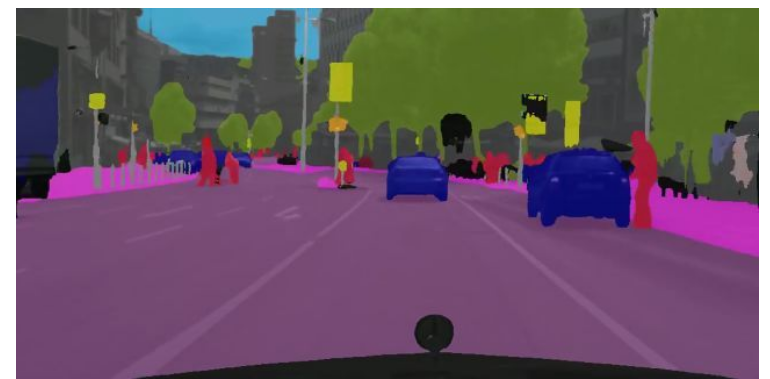

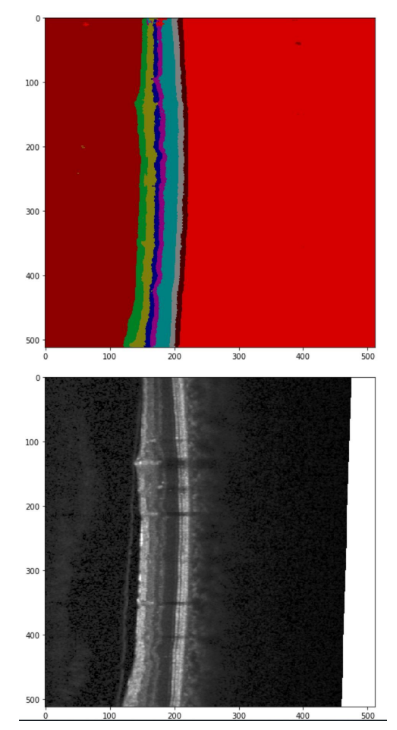

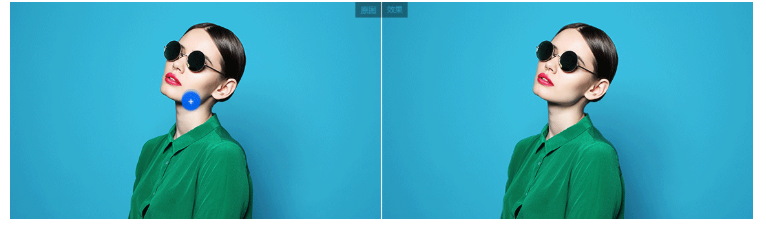

#### 6.1.2 图像分割算法
- 语义分割(Semantic Segmentatio)
    - FCN
    - U-Net
    - SegNet
    - DeepLab
- 实例分割(Instance Segmentation)
    - Mask-RCNN

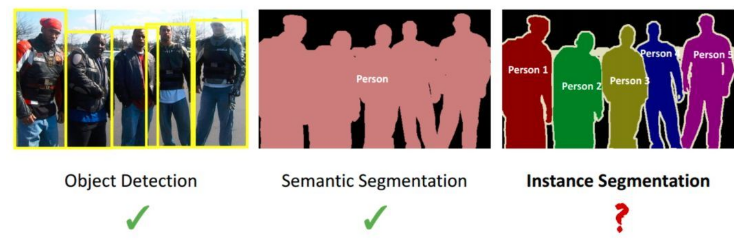

### 6.2 语义分割
#### 6.2.1 语义分割任务

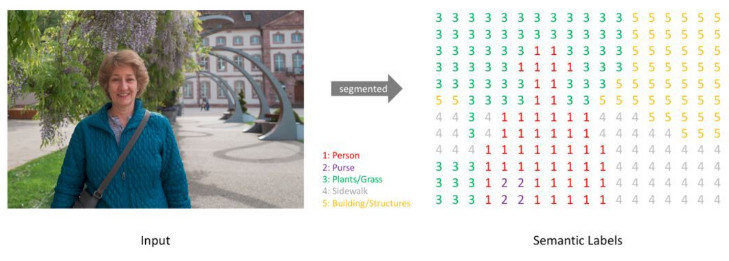  
> 从输入到输出语义标签

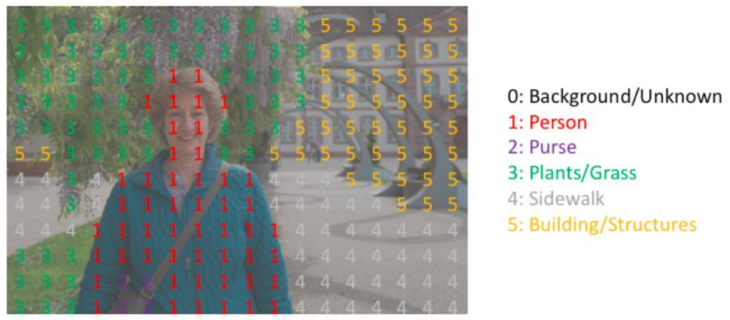  
> 语义标签与输入图像的重叠

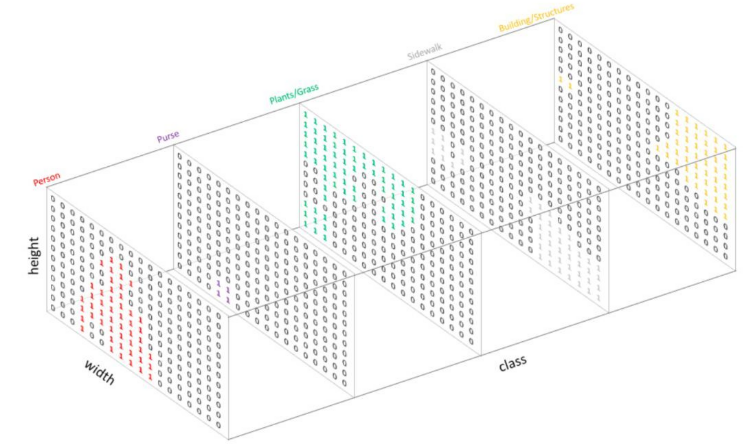  
> 语义标签的 one-hot

**语义分割通用网络结构**

- 全卷积
- 下采样
- 上采样

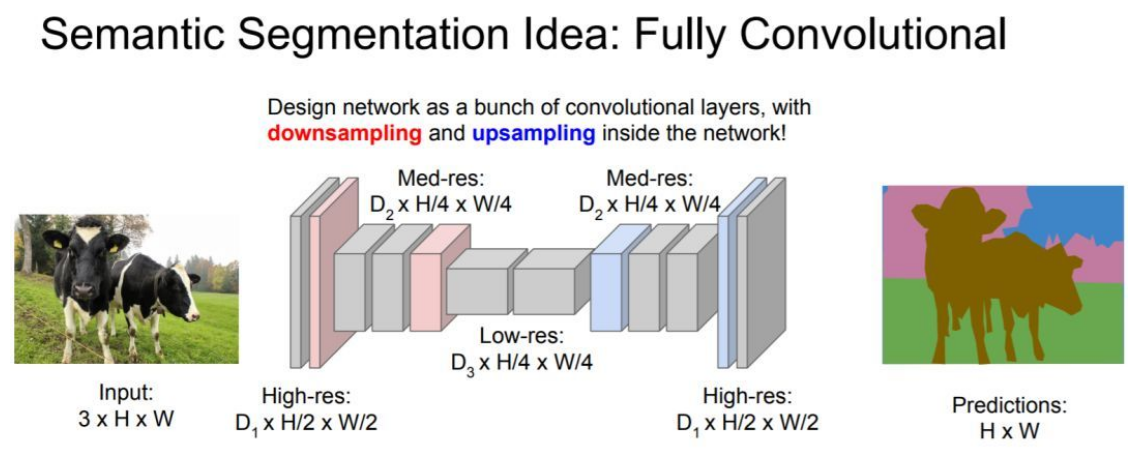

#### 6.2.2 FCN
- 全卷积化(Fully Convolutional)：用于解决逐像素(pixel-wise)的预测问题。
- 反卷积(deconvolution) ：上采样操作，用于恢复图片尺寸，方便后续进行逐像素预测;
- 跳跃结构(skip architecture)：用于融合高低层特征信息。通过跨层连接的结构，结合了网络浅层的细(fine-grain)粒度信息信息以及深层的粗糙(coarse)信息，以实现精准的分割任务。

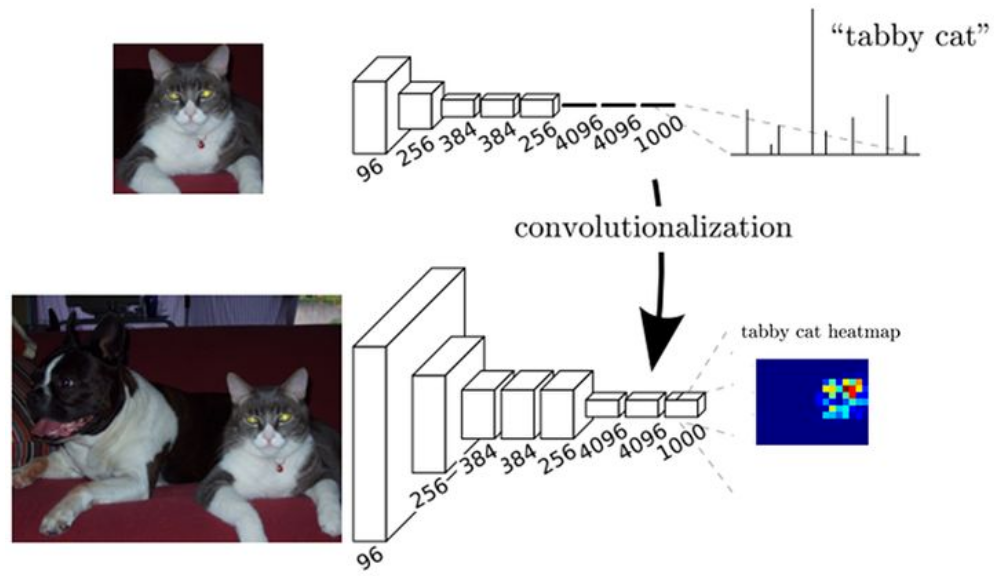

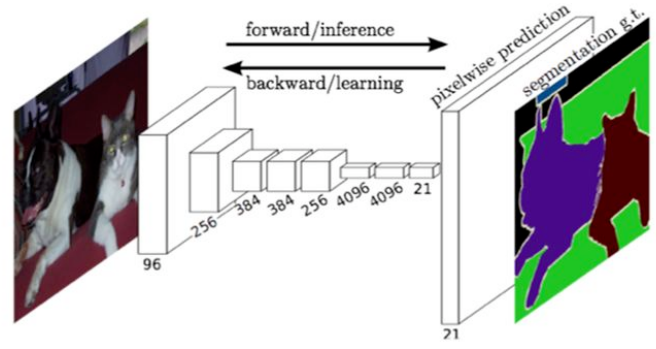

**FCN：deconvolution**

- 结果不够精细
- 对各个像素进行分类，没有充分考虑像素与像素之间的关系。

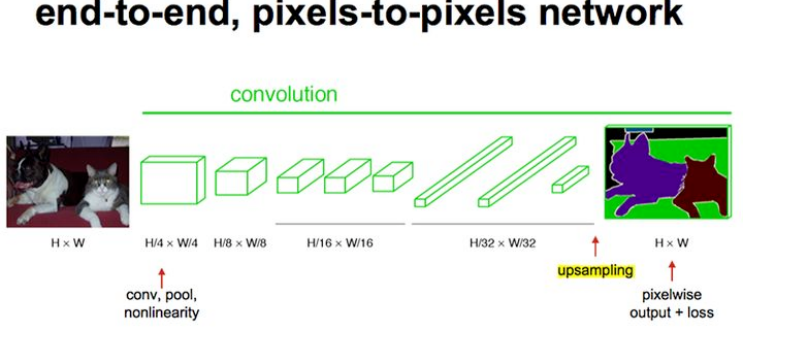

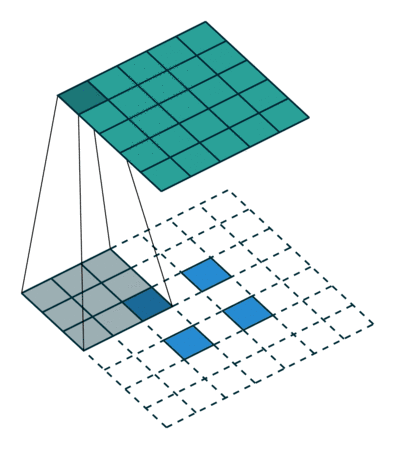

**FCN：skip architecture**

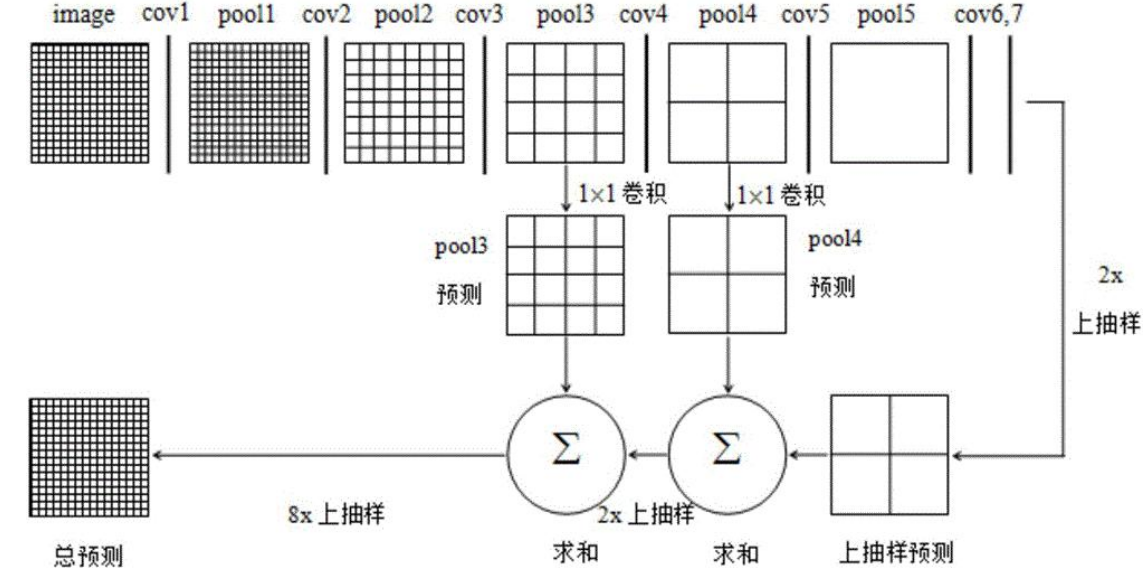

#### 6.2.3 U-Net
- 结构类似FCN
- 使用concat操作
- 主要用于医学影像分割

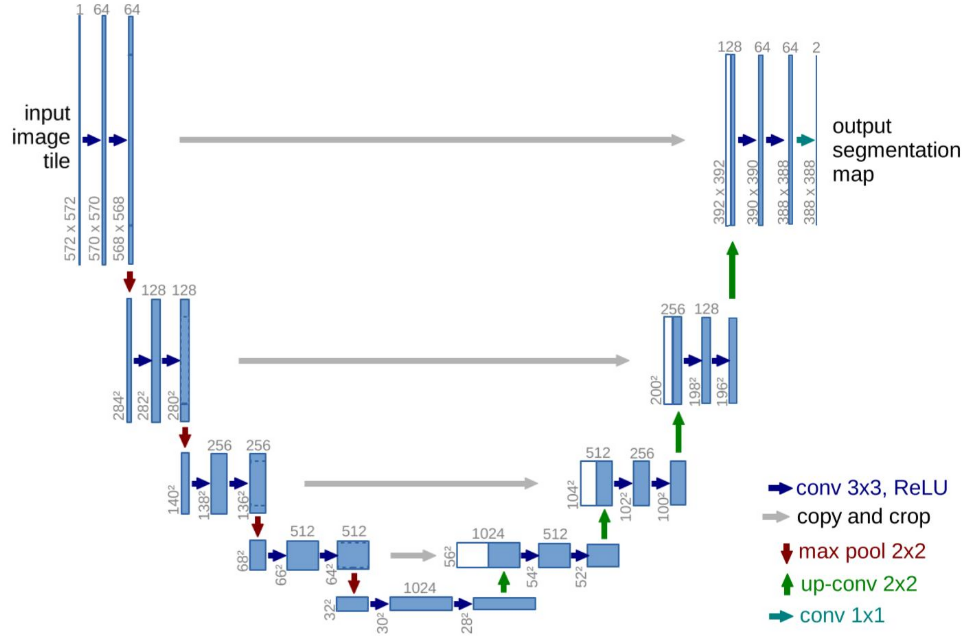

#### 6.2.4 SegNet
- Encoder编码器:
    - 在编码器处，执行卷积和最大池化。
    - VGG-16有13个卷积层。 （不用全连接的层）
    - 在进行2×2最大池化时，存储相应的最大池化索引（位置）。 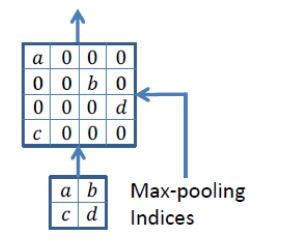
- Decoder解码器
    - 在解码器处，执行上采样和卷积。最后，每个像素送到softmax分类器。
    - 在上采样期间，如上所示，调用相应编码器层处的最大池化索引以进行上采样。
    - 最后，使用K类softmax分类器来预测每个像素的类别。  
    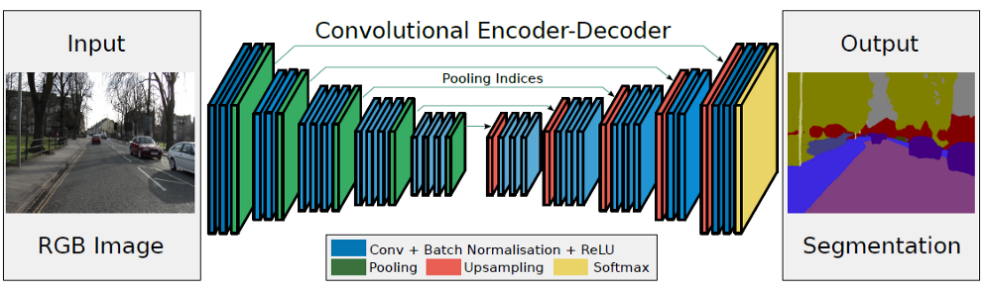

#### 6.2.5 DeepLabv1
- 空洞卷积 ：对backbone的最后一个block卷积步幅设置为1，使用rate=2的空洞卷积替代原有后续的所有卷积，使得输出变小，避免池化层丢失图像信息；
CRF优化精度：对最终的输出层结果每个像素点之间增加连接，就是每个像素点作为节点，像素与像素间的关系作为边，通过二元势函数描述像素点与像素点之间的关系，鼓励相似像素分配相同的标签，而相差较大的像素分配不同标签，- 而这个“距离”的定义与颜色值和实际相对距离有关。

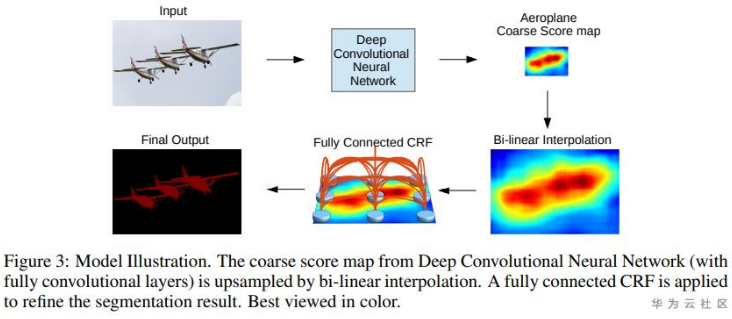

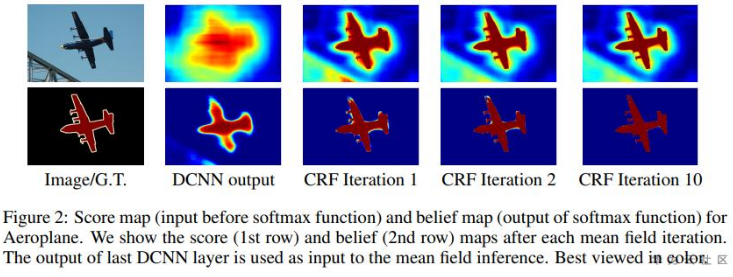

#### 6.2.6 DeepLab V2
- DeepLab V2主要增加了带空洞卷积的空间金字塔池ASPP（Atrous Spatial Pyramid Pooling）结构，以及替换了原有的VGG骨架，使用了ResNet。

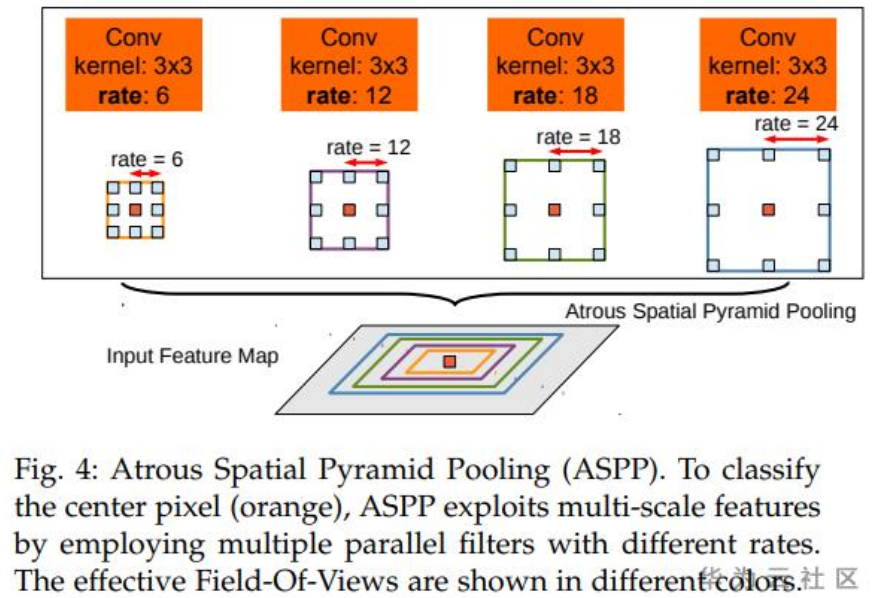

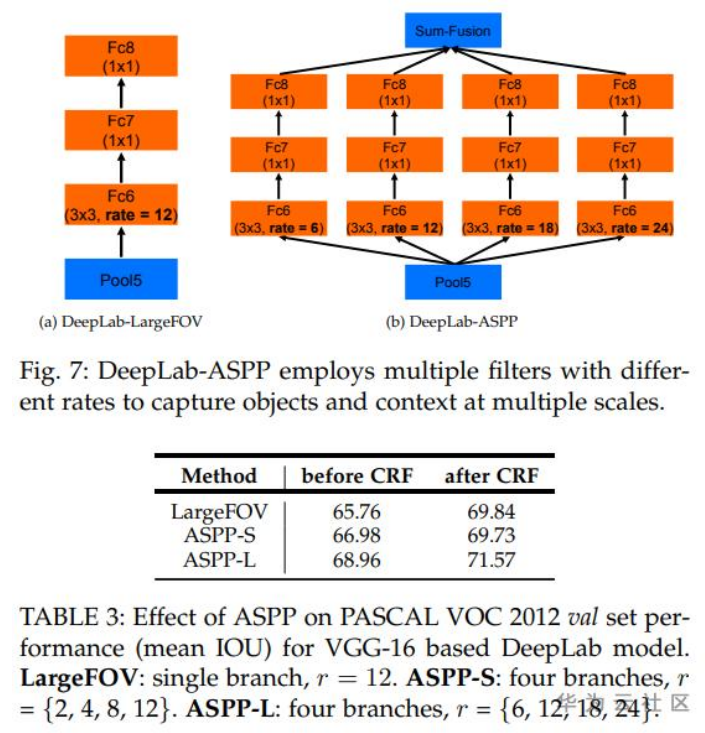  
> 不同的物体在图像中有不同的尺寸，ASPP结构可以考虑不同的物体比例，提高最终的模型精度。下图为ASPP结构相比单一分支空洞卷积的对比，显然不同尺寸的ASPP效果更好。

#### 6.2.7 DeepLab V3
DeepLab V3主要改进了以下几点：

- 去掉CRF模块
- 改进了ASPP，在ASPP中加入BN层
- 在级联模块中应用空洞卷积

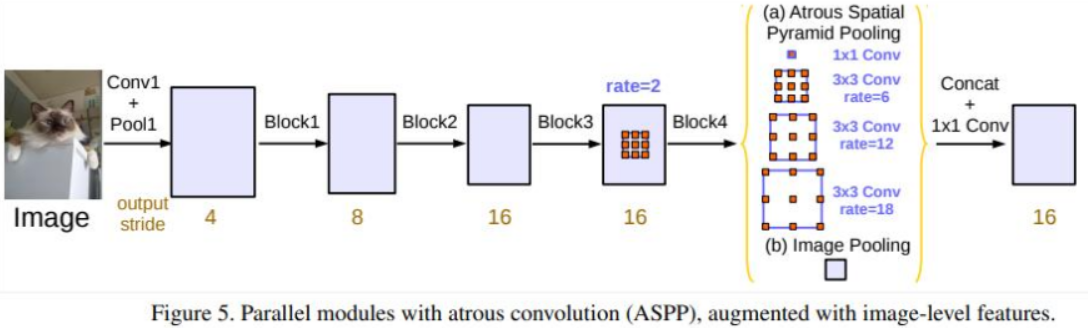
> 相比V2的ASPP增加了1x1的conv以及global avg pooling，同时对每个空洞卷积增加了BN。其中之所以增加1x1卷积是因为大采样率的3×3空洞卷积由于图像边界效应无法捕获长程信息，于是将退化为1×1的卷积。


#### 6.2.8 DeepLab V3+
DeepLab V3+主要改进了以下几点：

- 增加Decoder模块，精细化物体边缘；
- 改进backbone

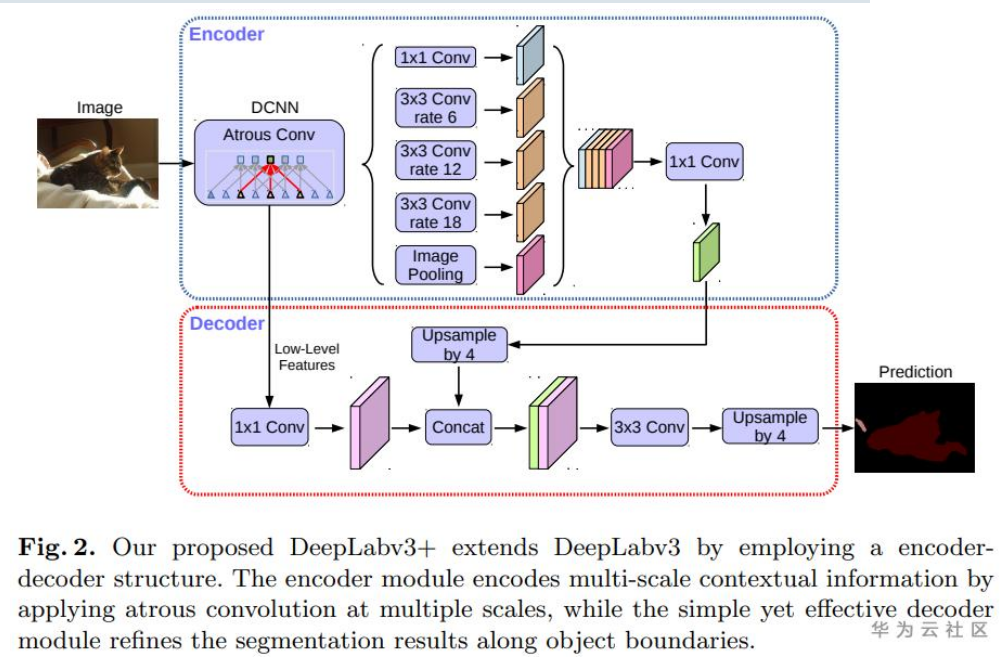

### 6.3 实例分割(Mask RCNN)
#### 6.3.1 实例分割任务
- 相较于语义分割，实例分割不仅要做出像素级别的分类，还要在此基础上将同一类别不同个体分出来，即做到每个实例的分割。
- 实例分割的基本思路就是在语义分割的基础上加上目标检测，先用目标检测算法将图像中的实例进行定位，再用语义分割方法对不同定位框中的目标物体进行标记，从而达到实例分割的目的。
- Mask R-CNN 是 2017 年何恺明等大佬基于此前的两阶段目标检测算法推出的顶级网络。

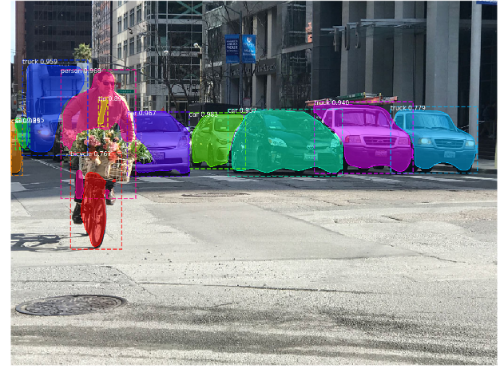

#### 6.3.2 Mask RCNN网络架构

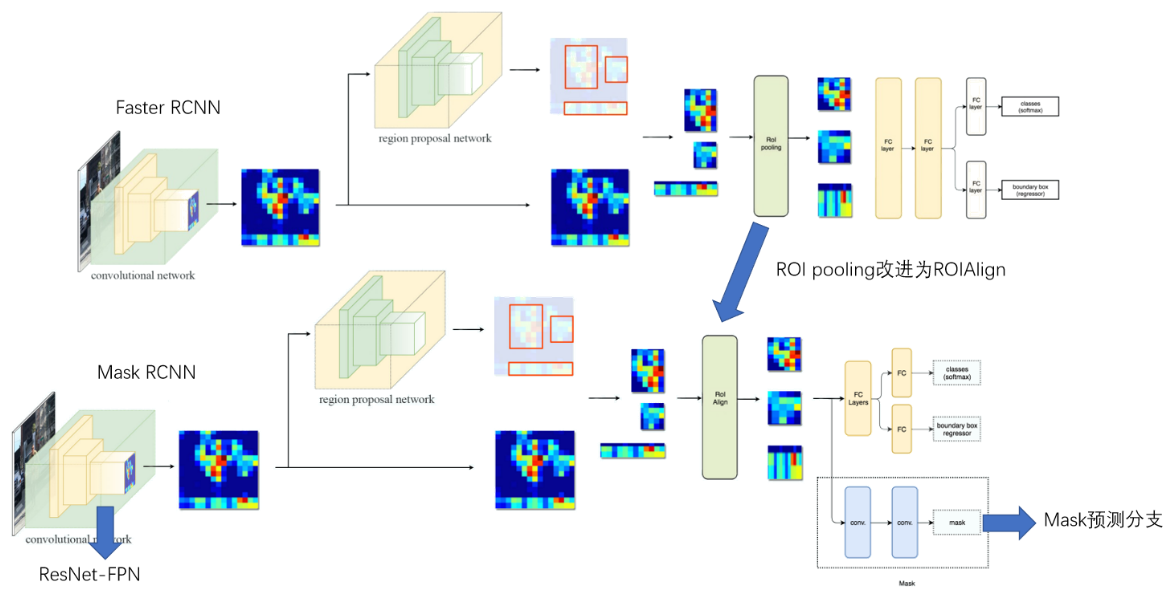

#### 6.3.3 ROI Align
**ROI pooling存在的问题-两次整数化导致回归位置偏差**

- region proposal的xywh通常是小数，但是为了方便操作会把它整数化。
- 将整数化后的边界区域平均分割成 k x k 个单元，对每一个单元的边界进行整数化。

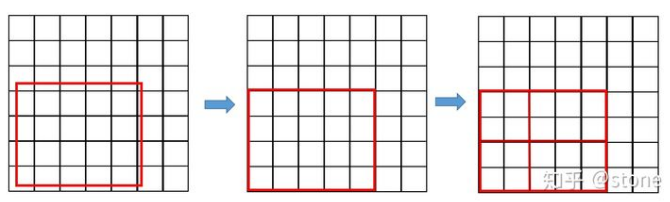 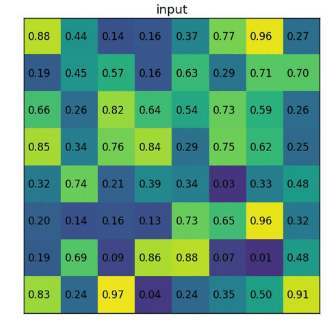

**ROI Align**

- RoIAlign 是通过取消量化操作，使用双线性内插值（bilinear interpolation ）方法来获得坐标为浮点数的像素点上的数值，将整个特征聚集过程转化为一个连续的操作。 操作的流程如下：
- 遍历每一个候选区域，保持浮点数边界不做量化
- 将候选区域分成 k×k 个区域，每个边界的单元不做量化
- 在每个计算单元中固定四个坐标位置，使用双线性内插的方法计算四个位置的值，然后进行最大池化操作

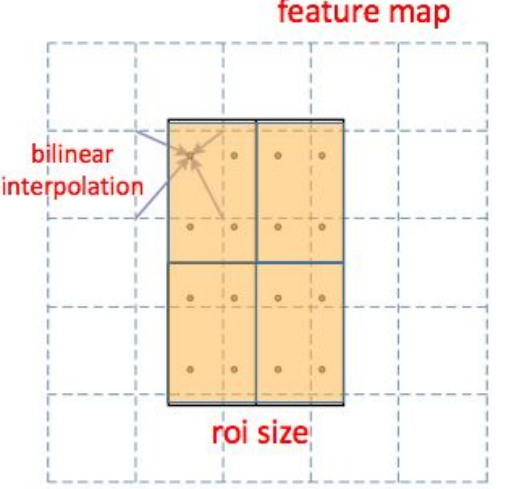

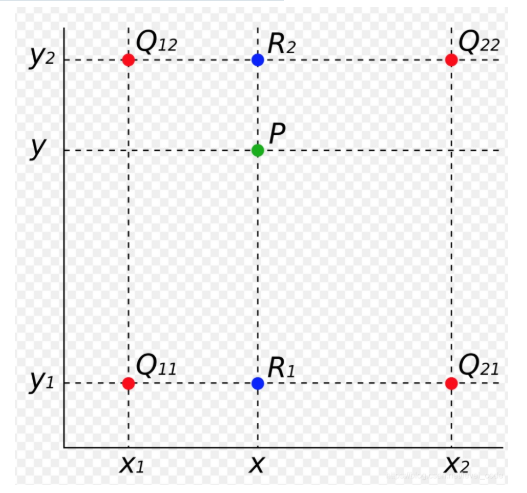